# Balancing Cost per Unit Volume: IV Algorithm vs Real ELEXON (2024)

This notebook combines the daily cost and volume comparisons from the previous analyses to compute the **unit cost of balancing** (£/MWh) for both the IV zonal clearing algorithm and real ELEXON accepted actions.

This is a key metric because it normalises for the volume difference: the IV model works with lower volumes (congestion-only, calibrated to a subset of BMUs), while the real data includes all BM actions. Comparing £/MWh reveals whether the two approaches price each MWh of balancing similarly, regardless of how much total volume they process.

**Data sources:**
- **IV cost**: `IV_clearing_settlement_summary_flex.csv` → `total_cost_gbp`
- **IV volume**: same file → `cleared_volume_mwh` × 0.5 (MW per SP → MWh)
- **Real cost**: `bids.csv` + `offers.csv` → vol × price × 0.5
- **Real volume**: same files → sum of vol × 0.5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ROOT = Path(r"c:\GBPower")
RESULTS_DIR = ROOT / "results"
DATA_DIR = ROOT / "data" / "base"

all_dates = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("2024")])
print(f"Found {len(all_dates)} result date folders (2024)")
print(f"Date range: {all_dates[0]} to {all_dates[-1]}")

Found 366 result date folders (2024)
Date range: 2024-01-01 to 2024-12-31


## Load Daily Costs and Volumes

Recompute both cost and volume for each day from the source files so this notebook is self-contained.

In [2]:
def compute_real_daily(day_str):
    """Compute real ELEXON cost and volume for one day."""
    base_path = DATA_DIR / day_str
    result = {
        'real_offer_cost': np.nan, 'real_bid_cost': np.nan, 'real_total_cost': np.nan,
        'real_offer_vol': np.nan, 'real_bid_vol': np.nan, 'real_total_vol': np.nan,
    }
    
    for file_type in ['offers', 'bids']:
        fpath = base_path / f"{file_type}.csv"
        if not fpath.exists():
            continue
        
        df = pd.read_csv(fpath, index_col=[0, 1])
        vols = df.loc[pd.IndexSlice[:, 'vol'], :]
        prices = df.loc[pd.IndexSlice[:, 'price'], :]
        vols.index = vols.index.droplevel(1)
        prices.index = prices.index.droplevel(1)
        
        vol_mwh = vols.sum().sum() * 0.5
        cost_gbp = (vols * prices * 0.5).sum().sum()
        
        if file_type == 'offers':
            result['real_offer_cost'] = cost_gbp
            result['real_offer_vol'] = vol_mwh
        else:
            result['real_bid_cost'] = cost_gbp
            result['real_bid_vol'] = vol_mwh
    
    if not np.isnan(result['real_offer_cost']) or not np.isnan(result['real_bid_cost']):
        result['real_total_cost'] = np.nansum([result['real_offer_cost'], result['real_bid_cost']])
        result['real_total_vol'] = np.nansum([result['real_offer_vol'], result['real_bid_vol']])
    
    return result


def compute_iv_daily(day_str):
    """Compute IV algorithm cost and volume for one day."""
    fpath = RESULTS_DIR / day_str / "IV_clearing_settlement_summary_flex.csv"
    if not fpath.exists():
        return {'iv_total_cost': np.nan, 'iv_total_vol': np.nan,
                'iv_up_vol': np.nan, 'iv_down_vol': np.nan,
                'iv_up_cost': np.nan, 'iv_down_cost': np.nan}
    
    df = pd.read_csv(fpath)
    
    up_vol = df.loc[df['direction'] == 'up', 'cleared_volume_mwh'].sum() * 0.5
    down_vol = df.loc[df['direction'] == 'down', 'cleared_volume_mwh'].sum() * 0.5
    up_cost = df.loc[df['direction'] == 'up', 'total_cost_gbp'].sum()
    down_cost = df.loc[df['direction'] == 'down', 'total_cost_gbp'].sum()
    
    return {
        'iv_total_cost': up_cost + down_cost,
        'iv_total_vol': up_vol + down_vol,
        'iv_up_vol': up_vol, 'iv_down_vol': down_vol,
        'iv_up_cost': up_cost, 'iv_down_cost': down_cost,
    }


rows = []
for day in tqdm(all_dates, desc="Loading daily cost & volume"):
    iv = compute_iv_daily(day)
    real = compute_real_daily(day)
    rows.append({'date': pd.Timestamp(day), **iv, **real})

df = pd.DataFrame(rows).set_index('date')

# Keep only days with both IV and real data
df_clean = df.dropna(subset=['iv_total_cost', 'real_total_cost']).copy()
print(f"Loaded {len(df)} days, {len(df_clean)} with both sources")

# Compute daily £/MWh
df_clean['iv_cost_per_mwh'] = df_clean['iv_total_cost'] / df_clean['iv_total_vol']
df_clean['real_cost_per_mwh'] = df_clean['real_total_cost'] / df_clean['real_total_vol']

# Also compute by direction
df_clean['iv_up_cost_per_mwh'] = df_clean['iv_up_cost'] / df_clean['iv_up_vol'].replace(0, np.nan)
df_clean['iv_down_cost_per_mwh'] = df_clean['iv_down_cost'] / df_clean['iv_down_vol'].replace(0, np.nan)
df_clean['real_offer_cost_per_mwh'] = df_clean['real_offer_cost'] / df_clean['real_offer_vol'].replace(0, np.nan)
df_clean['real_bid_cost_per_mwh'] = df_clean['real_bid_cost'] / df_clean['real_bid_vol'].replace(0, np.nan)

# Annual summaries
iv_annual = df_clean['iv_total_cost'].sum() / df_clean['iv_total_vol'].sum()
real_annual = df_clean['real_total_cost'].sum() / df_clean['real_total_vol'].sum()
print(f"\nAnnual average unit cost:")
print(f"  IV Algorithm:  £{iv_annual:.2f}/MWh")
print(f"  Real ELEXON:   £{real_annual:.2f}/MWh")
print(f"  Difference:    £{iv_annual - real_annual:.2f}/MWh ({(iv_annual/real_annual - 1)*100:+.1f}%)")

df_clean.head()

Loading daily cost & volume: 100%|██████████| 366/366 [00:07<00:00, 47.45it/s]

Loaded 366 days, 361 with both sources

Annual average unit cost:
  IV Algorithm:  £50.54/MWh
  Real ELEXON:   £61.92/MWh
  Difference:    £-11.38/MWh (-18.4%)


,iv_total_cost,iv_total_vol,iv_up_vol,iv_down_vol,iv_up_cost,iv_down_cost,real_offer_cost,real_bid_cost,real_total_cost,real_offer_vol,real_bid_vol,real_total_vol,iv_cost_per_mwh,real_cost_per_mwh,iv_up_cost_per_mwh,iv_down_cost_per_mwh,real_offer_cost_per_mwh,real_bid_cost_per_mwh
date,,,,,,,,,,,,,,,,,,
2024-01-03,8.306200e+03,371.490,185.745,185.745,836.40000,7469.80,1.054740e+06,-223838.996755,830901.059914,8427.808965,7042.249840,15470.058805,22.359148,53.710272,4.502948,40.215349,125.149972,-31.785154
2024-01-04,2.934790e+05,8285.370,4142.685,4142.685,79212.22680,214266.74,1.084312e+06,-342970.852657,741340.805557,9293.258405,9257.001110,18550.259515,35.421347,39.963905,19.120987,51.721707,116.677231,-37.049888
2024-01-05,0.000000e+00,0.000,0.000,0.000,0.00000,0.00,7.403890e+05,-342426.248510,397962.718573,6180.312210,6022.823490,12203.135700,NaN,32.611513,NaN,NaN,119.797988,-56.854771
2024-01-06,7.381055e+04,2682.460,1341.230,1341.230,13455.20385,60355.35,1.079805e+06,-756403.944426,323400.656504,8165.928410,13949.836890,22115.765300,27.515994,14.623082,10.031988,45.000000,132.232925,-54.223139
2024-01-07,1.422090e+06,12245.065,6122.520,6122.545,544231.46900,877858.68,1.102931e+06,-733125.567826,369805.119178,9495.787020,12149.548755,21645.335775,116.135778,17.084749,88.890109,143.381336,116.149476,-60.341794


## Plot 1: Daily Unit Cost Time Series

Daily £/MWh for both IV algorithm and real ELEXON over the full year.

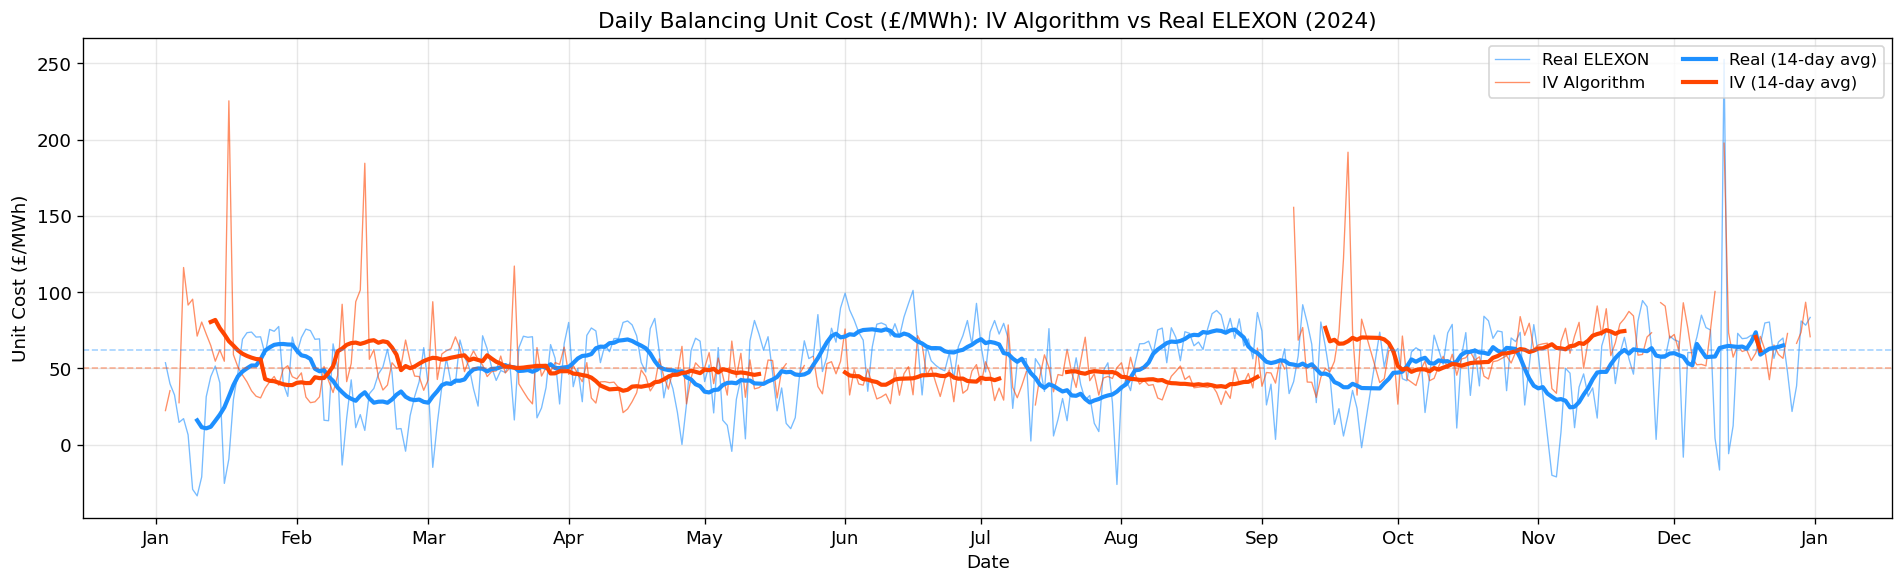

In [3]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_clean.index, df_clean['real_cost_per_mwh'], color='dodgerblue',
        alpha=0.6, linewidth=0.8, label='Real ELEXON')
ax.plot(df_clean.index, df_clean['iv_cost_per_mwh'], color='orangered',
        alpha=0.6, linewidth=0.8, label='IV Algorithm')

# 14-day rolling averages for readability
ax.plot(df_clean.index, df_clean['real_cost_per_mwh'].rolling(14, center=True).mean(),
        color='dodgerblue', linewidth=2.5, label='Real (14-day avg)')
ax.plot(df_clean.index, df_clean['iv_cost_per_mwh'].rolling(14, center=True).mean(),
        color='orangered', linewidth=2.5, label='IV (14-day avg)')

ax.axhline(real_annual, color='dodgerblue', ls='--', alpha=0.4, linewidth=1)
ax.axhline(iv_annual, color='orangered', ls='--', alpha=0.4, linewidth=1)

ax.set_ylabel('Unit Cost (£/MWh)')
ax.set_xlabel('Date')
ax.set_title('Daily Balancing Unit Cost (£/MWh): IV Algorithm vs Real ELEXON (2024)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_unit_cost_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2: Monthly Average Unit Cost Comparison

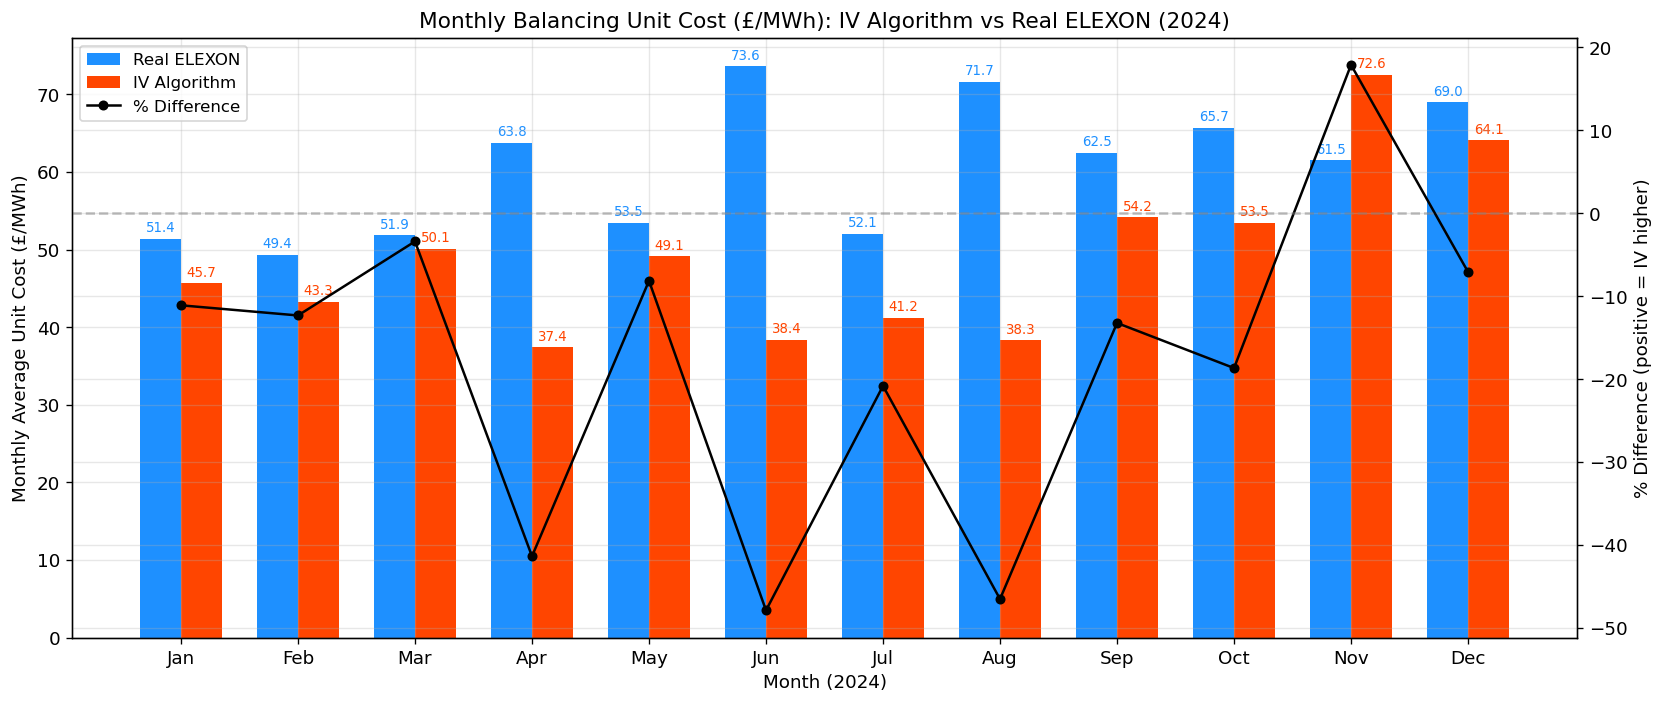

Monthly unit cost summary:
            iv_cpm  real_cpm  pct_diff
date                                  
2024-01-01   45.70     51.40    -11.10
2024-02-01   43.27     49.36    -12.32
2024-03-01   50.11     51.88     -3.40
2024-04-01   37.40     63.76    -41.35
2024-05-01   49.13     53.48     -8.14
2024-06-01   38.38     73.64    -47.88
2024-07-01   41.24     52.08    -20.81
2024-08-01   38.33     71.66    -46.51
2024-09-01   54.20     62.46    -13.23
2024-10-01   53.46     65.73    -18.67
2024-11-01   72.55     61.54     17.89
2024-12-01   64.11     68.99     -7.08


In [4]:
monthly = df_clean.resample('MS').agg({
    'iv_total_cost': 'sum',
    'iv_total_vol': 'sum',
    'real_total_cost': 'sum',
    'real_total_vol': 'sum',
})
monthly['iv_cpm'] = monthly['iv_total_cost'] / monthly['iv_total_vol']
monthly['real_cpm'] = monthly['real_total_cost'] / monthly['real_total_vol']
monthly['pct_diff'] = (monthly['iv_cpm'] / monthly['real_cpm'] - 1) * 100

month_labels = [d.strftime('%b') for d in monthly.index]
x = np.arange(len(monthly))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 6))

bars_real = ax1.bar(x - width/2, monthly['real_cpm'], width, color='dodgerblue', label='Real ELEXON')
bars_iv = ax1.bar(x + width/2, monthly['iv_cpm'], width, color='orangered', label='IV Algorithm')

# Add value labels
for bar in bars_real:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=8, color='dodgerblue')
for bar in bars_iv:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=8, color='orangered')

# % difference line
ax2 = ax1.twinx()
ax2.plot(x, monthly['pct_diff'], 'ko-', markersize=5, linewidth=1.5, label='% Difference')
ax2.axhline(0, color='grey', ls='--', alpha=0.5)
ax2.set_ylabel('% Difference (positive = IV higher)', color='black')

ax1.set_xticks(x)
ax1.set_xticklabels(month_labels)
ax1.set_xlabel('Month (2024)')
ax1.set_ylabel('Monthly Average Unit Cost (£/MWh)')
ax1.set_title('Monthly Balancing Unit Cost (£/MWh): IV Algorithm vs Real ELEXON (2024)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_unit_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monthly unit cost summary:")
print(monthly[['iv_cpm', 'real_cpm', 'pct_diff']].round(2).to_string())

## Plot 3: Daily Unit Cost Scatter (IV vs Real)

Each point is one day. A point on the diagonal means the two approaches agree on that day's £/MWh.

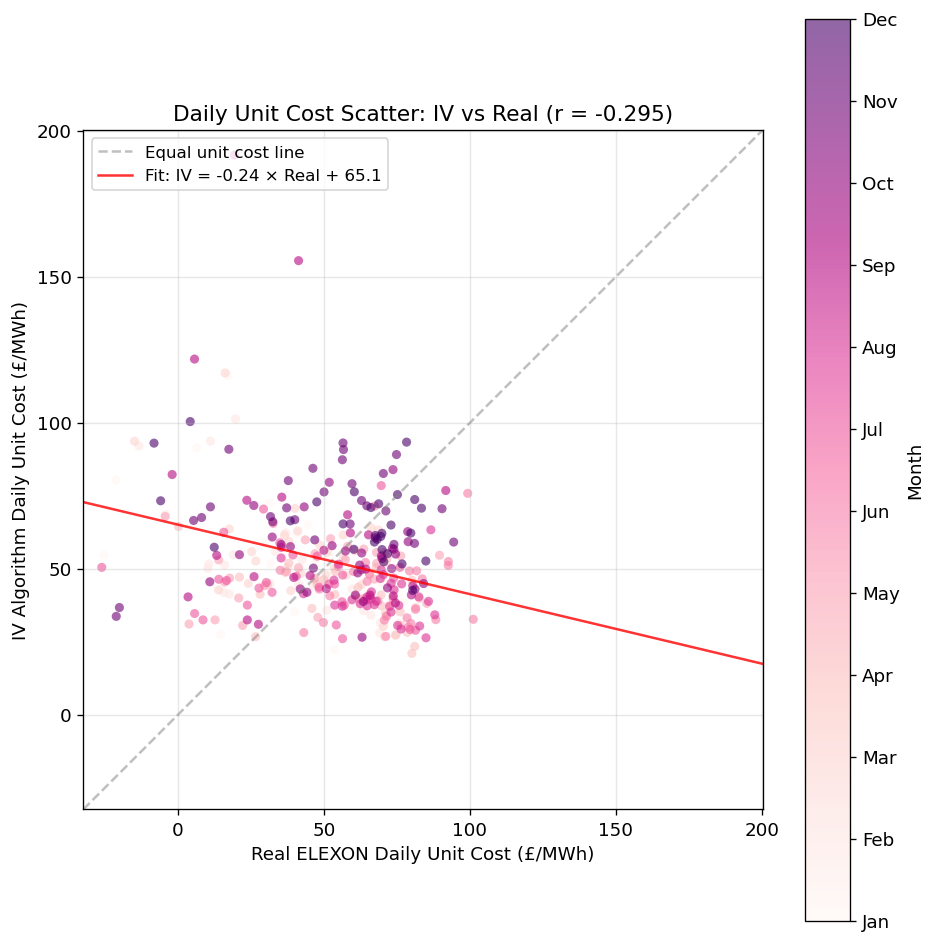

In [5]:
# Filter out extreme outliers for readable scatter (> 99.5th percentile)
upper = max(df_clean['iv_cost_per_mwh'].quantile(0.995), df_clean['real_cost_per_mwh'].quantile(0.995))
lower = min(df_clean['iv_cost_per_mwh'].quantile(0.005), df_clean['real_cost_per_mwh'].quantile(0.005))
mask = (df_clean['iv_cost_per_mwh'].between(lower, upper)) & (df_clean['real_cost_per_mwh'].between(lower, upper))
df_scatter = df_clean[mask]

months_num = df_scatter.index.month
r = df_scatter[['iv_cost_per_mwh', 'real_cost_per_mwh']].corr().iloc[0, 1]

# Linear fit
m, b = np.polyfit(df_scatter['real_cost_per_mwh'], df_scatter['iv_cost_per_mwh'], 1)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(df_scatter['real_cost_per_mwh'], df_scatter['iv_cost_per_mwh'],
                c=months_num, cmap='RdPu', alpha=0.6, s=30, edgecolors='none')

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='grey', alpha=0.5, label='Equal unit cost line')

x_fit = np.linspace(lims[0], lims[1], 100)
ax.plot(x_fit, m * x_fit + b, '-', color='red', alpha=0.8,
        label=f'Fit: IV = {m:.2f} × Real + {b:.1f}')

ax.set_xlabel('Real ELEXON Daily Unit Cost (£/MWh)')
ax.set_ylabel('IV Algorithm Daily Unit Cost (£/MWh)')
ax.set_title(f'Daily Unit Cost Scatter: IV vs Real (r = {r:.3f})')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(loc='upper left')

cbar = plt.colorbar(sc, ax=ax, label='Month')
cbar.set_ticks(range(1, 13))
cbar.set_ticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_unit_cost_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Directional Unit Cost (Offers vs Bids)

Break down the unit cost by direction: how much does each MWh of turn-up (offers) vs turndown (bids) cost?

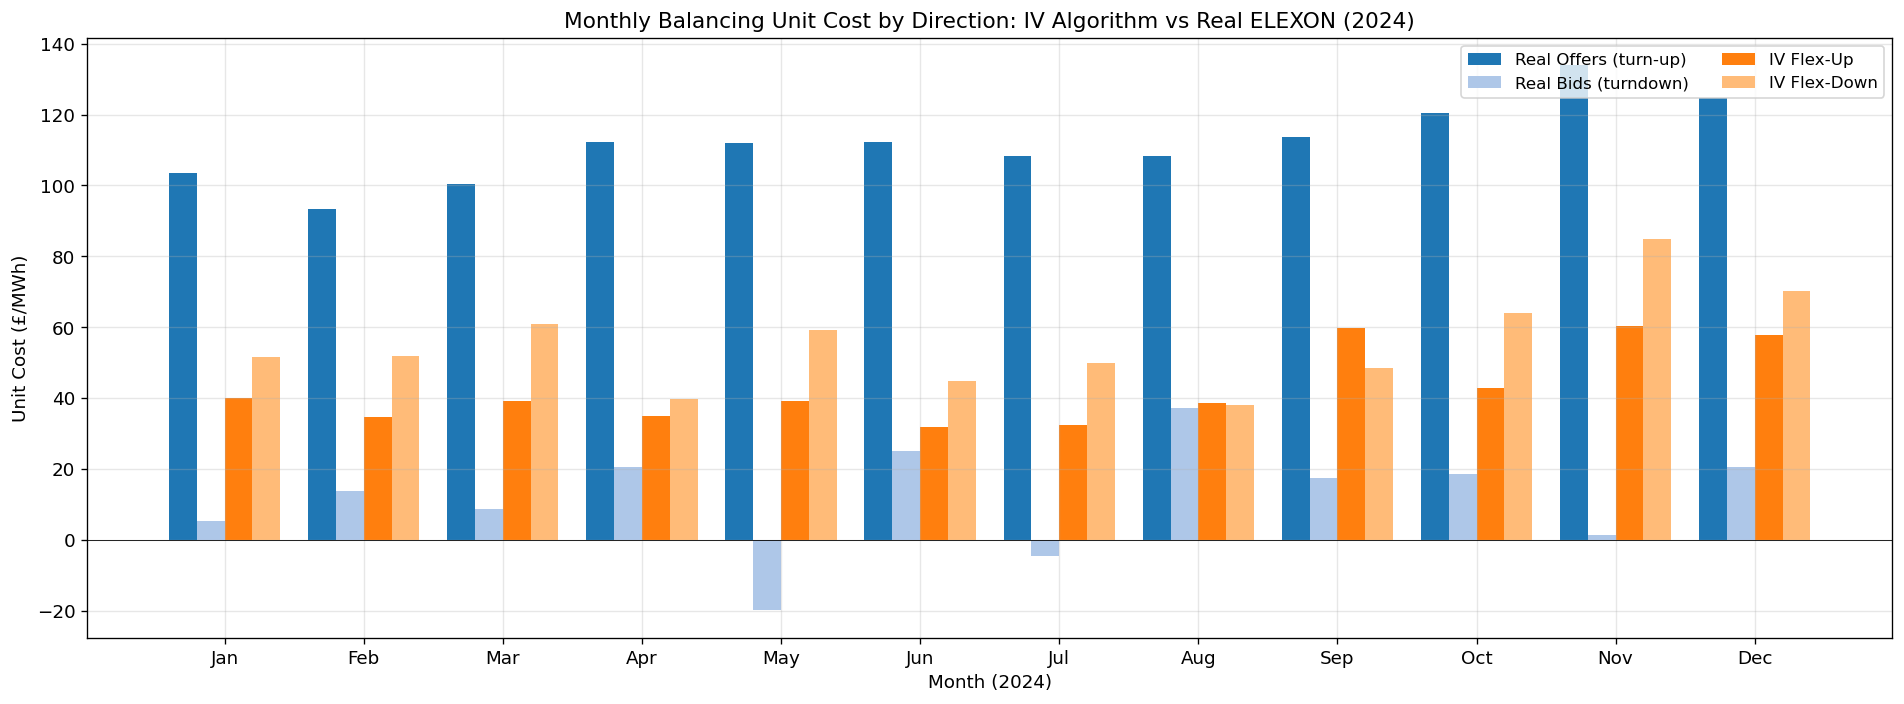

In [6]:
dir_monthly = df_clean.resample('MS').agg({
    'iv_up_cost': 'sum', 'iv_up_vol': 'sum',
    'iv_down_cost': 'sum', 'iv_down_vol': 'sum',
    'real_offer_cost': 'sum', 'real_offer_vol': 'sum',
    'real_bid_cost': 'sum', 'real_bid_vol': 'sum',
})
dir_monthly['iv_up_cpm'] = dir_monthly['iv_up_cost'] / dir_monthly['iv_up_vol'].replace(0, np.nan)
dir_monthly['iv_down_cpm'] = dir_monthly['iv_down_cost'] / dir_monthly['iv_down_vol'].replace(0, np.nan)
dir_monthly['real_offer_cpm'] = dir_monthly['real_offer_cost'] / dir_monthly['real_offer_vol'].replace(0, np.nan)
dir_monthly['real_bid_cpm'] = dir_monthly['real_bid_cost'] / dir_monthly['real_bid_vol'].replace(0, np.nan)

month_labels = [d.strftime('%b') for d in dir_monthly.index]
x = np.arange(len(dir_monthly))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - 1.5*width, dir_monthly['real_offer_cpm'], width, color='#1f77b4', label='Real Offers (turn-up)')
ax.bar(x - 0.5*width, dir_monthly['real_bid_cpm'], width, color='#aec7e8', label='Real Bids (turndown)')
ax.bar(x + 0.5*width, dir_monthly['iv_up_cpm'], width, color='#ff7f0e', label='IV Flex-Up')
ax.bar(x + 1.5*width, dir_monthly['iv_down_cpm'], width, color='#ffbb78', label='IV Flex-Down')

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month (2024)')
ax.set_ylabel('Unit Cost (£/MWh)')
ax.set_title('Monthly Balancing Unit Cost by Direction: IV Algorithm vs Real ELEXON (2024)')
ax.legend(loc='upper right', ncol=2)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_directional_unit_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 5: Daily Unit Cost Difference (£/MWh)

Bar chart showing the daily **unit cost** difference (Real £/MWh − IV £/MWh), coloured by which approach is cheaper per MWh. This isolates pricing efficiency from volume effects: a green bar means the IV algorithm prices each MWh of balancing more cheaply, regardless of how much total volume it clears.

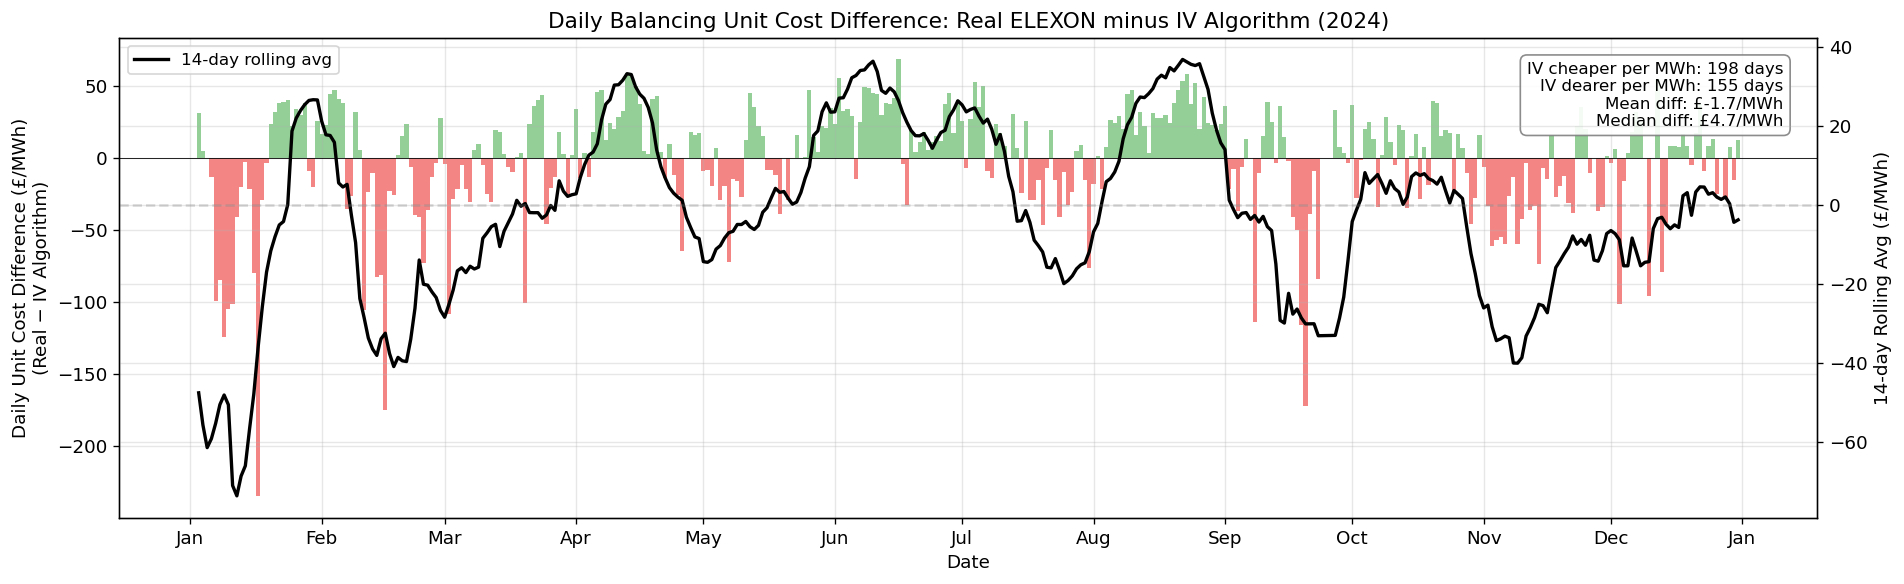

In [12]:
# Daily unit cost difference: Real £/MWh minus IV £/MWh (positive = IV cheaper per MWh)
df_clean['unit_cost_diff'] = df_clean['real_cost_per_mwh'] - df_clean['iv_cost_per_mwh']
df_clean['cum_unit_cost_diff'] = df_clean['unit_cost_diff'].cumsum()

colors = ['#66bb6a' if d >= 0 else '#ef5350' for d in df_clean['unit_cost_diff']]
n_cheaper_pmwh = (df_clean['unit_cost_diff'] >= 0).sum()
n_costlier_pmwh = (df_clean['unit_cost_diff'] < 0).sum()

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.bar(df_clean.index, df_clean['unit_cost_diff'], color=colors, width=1.0, alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Daily Unit Cost Difference (£/MWh)\n(Real − IV Algorithm)')
ax1.set_xlabel('Date')
ax1.set_title('Daily Balancing Unit Cost Difference: Real ELEXON minus IV Algorithm (2024)')
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Rolling average on right axis
rolling_diff = df_clean['unit_cost_diff'].rolling(14, center=True, min_periods=1).mean()
ax2 = ax1.twinx()
ax2.plot(df_clean.index, rolling_diff, color='black', linewidth=2, label='14-day rolling avg')
ax2.axhline(0, color='grey', ls='--', alpha=0.3)
ax2.set_ylabel('14-day Rolling Avg (£/MWh)')
ax2.legend(loc='upper left')

# Annotation box
mean_diff = df_clean['unit_cost_diff'].mean()
median_diff = df_clean['unit_cost_diff'].median()
bbox_text = (f'IV cheaper per MWh: {n_cheaper_pmwh} days\n'
             f'IV dearer per MWh: {n_costlier_pmwh} days\n'
             f'Mean diff: £{mean_diff:.1f}/MWh\n'
             f'Median diff: £{median_diff:.1f}/MWh')
ax1.annotate(bbox_text, xy=(0.98, 0.95), xycoords='axes fraction',
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='grey', alpha=0.9))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_unit_cost_diff.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

In [7]:
# Overall annual £/MWh
iv_ann = df_clean['iv_total_cost'].sum() / df_clean['iv_total_vol'].sum()
real_ann = df_clean['real_total_cost'].sum() / df_clean['real_total_vol'].sum()

# By direction
iv_up_ann = df_clean['iv_up_cost'].sum() / df_clean['iv_up_vol'].sum()
iv_dn_ann = df_clean['iv_down_cost'].sum() / df_clean['iv_down_vol'].sum()
real_off_ann = df_clean['real_offer_cost'].sum() / df_clean['real_offer_vol'].sum()
real_bid_ann = df_clean['real_bid_cost'].sum() / df_clean['real_bid_vol'].sum()

# Daily distribution
r_daily = df_clean[['iv_cost_per_mwh', 'real_cost_per_mwh']].corr().iloc[0, 1]

summary = pd.DataFrame({
    'Value': [
        f'£{iv_ann:.2f}',
        f'  £{iv_up_ann:.2f}',
        f'  £{iv_dn_ann:.2f}',
        f'£{real_ann:.2f}',
        f'  £{real_off_ann:.2f}',
        f'  £{real_bid_ann:.2f}',
        f'£{iv_ann - real_ann:.2f} ({(iv_ann/real_ann - 1)*100:+.1f}%)',
        f'£{df_clean["iv_cost_per_mwh"].median():.2f}',
        f'£{df_clean["real_cost_per_mwh"].median():.2f}',
        f'{r_daily:.3f}',
        f'{(df_clean["iv_cost_per_mwh"] < df_clean["real_cost_per_mwh"]).sum()}',
        f'{(df_clean["iv_cost_per_mwh"] >= df_clean["real_cost_per_mwh"]).sum()}',
        f'{len(df_clean)}',
    ]
}, index=[
    'IV Annual Unit Cost (£/MWh)',
    '  — Flex-Up (£/MWh)',
    '  — Flex-Down (£/MWh)',
    'Real Annual Unit Cost (£/MWh)',
    '  — Offers / turn-up (£/MWh)',
    '  — Bids / turndown (£/MWh)',
    'Difference (IV − Real)',
    'Median Daily IV £/MWh',
    'Median Daily Real £/MWh',
    'Pearson r (daily)',
    'Days IV cheaper per MWh',
    'Days IV dearer per MWh',
    'Days analysed',
])

print(summary.to_string())

                                          Value
IV Annual Unit Cost (£/MWh)              £50.54
  — Flex-Up (£/MWh)                      £44.39
  — Flex-Down (£/MWh)                    £56.70
Real Annual Unit Cost (£/MWh)            £61.92
  — Offers / turn-up (£/MWh)            £113.01
  — Bids / turndown (£/MWh)              £14.92
Difference (IV − Real)         £-11.38 (-18.4%)
Median Daily IV £/MWh                    £49.50
Median Daily Real £/MWh                  £56.68
Pearson r (daily)                        -0.169
Days IV cheaper per MWh                     198
Days IV dearer per MWh                      155
Days analysed                               361


In [15]:
# Quick investigation: what do bid prices actually look like?
# Sample one day to understand the sign convention and distribution
sample_day = '2024-06-15'
bids_path = DATA_DIR / sample_day / 'bids.csv'
bids_sample = pd.read_csv(bids_path, index_col=[0, 1])
prices = bids_sample.loc[pd.IndexSlice[:, 'price'], :]
prices.index = prices.index.droplevel(1)
vols = bids_sample.loc[pd.IndexSlice[:, 'vol'], :]
vols.index = vols.index.droplevel(1)

all_prices = prices.values.flatten()
all_prices = all_prices[~np.isnan(all_prices)]
all_vols = vols.values.flatten()
all_vols = all_vols[~np.isnan(all_vols)]

print(f"Sample day: {sample_day}")
print(f"\nBid PRICES (£/MWh):")
print(f"  Min: {all_prices.min():.2f}")
print(f"  Max: {all_prices.max():.2f}")
print(f"  Mean: {all_prices.mean():.2f}")
print(f"  Median: {np.median(all_prices):.2f}")
print(f"  % negative: {(all_prices < 0).sum() / len(all_prices) * 100:.1f}%")
print(f"  % positive: {(all_prices > 0).sum() / len(all_prices) * 100:.1f}%")
print(f"  % zero: {(all_prices == 0).sum() / len(all_prices) * 100:.1f}%")

print(f"\nBid VOLUMES (MW per SP):")
print(f"  Min: {all_vols.min():.2f}")
print(f"  Max: {all_vols.max():.2f}")
print(f"  Mean: {all_vols.mean():.2f}")

# Also check offers for comparison
offers_path = DATA_DIR / sample_day / 'offers.csv'
offers_sample = pd.read_csv(offers_path, index_col=[0, 1])
offer_prices = offers_sample.loc[pd.IndexSlice[:, 'price'], :].values.flatten()
offer_prices = offer_prices[~np.isnan(offer_prices)]
print(f"\nOffer PRICES for comparison (£/MWh):")
print(f"  Min: {offer_prices.min():.2f}")
print(f"  Max: {offer_prices.max():.2f}")
print(f"  Mean: {offer_prices.mean():.2f}")
print(f"  Median: {np.median(offer_prices):.2f}")

# What does cost = vol * price * 0.5 look like for bids?
cost_matrix = (vols * prices * 0.5)
total_bid_cost = cost_matrix.sum().sum()
total_bid_vol = (vols * 0.5).sum().sum()
print(f"\nThis day's real bid cost: £{total_bid_cost:,.0f}")
print(f"This day's real bid vol: {total_bid_vol:,.0f} MWh")
print(f"This day's real bid £/MWh: £{total_bid_cost/total_bid_vol:.2f}/MWh")

Sample day: 2024-06-15

Bid PRICES (£/MWh):
  Min: -70.00
  Max: 189.94
  Mean: -5.57
  Median: -46.00
  % negative: 83.4%
  % positive: 16.6%
  % zero: 0.0%

Bid VOLUMES (MW per SP):
  Min: 0.00
  Max: 210.00
  Mean: 15.26

Offer PRICES for comparison (£/MWh):
  Min: 88.00
  Max: 145.00
  Mean: 115.36
  Median: 115.91

This day's real bid cost: £200,220
This day's real bid vol: 7,338 MWh
This day's real bid £/MWh: £27.28/MWh


In [14]:
# Check what the IV clearing actually accepted — look at the settlement detail
iv_actions_path = RESULTS_DIR / sample_day / 'IV_clearing_accepted_actions_flex.csv'
if iv_actions_path.exists():
    iv_actions = pd.read_csv(iv_actions_path)
    
    # Show bid actions
    iv_bids = iv_actions[iv_actions['action_type'] == 'bid']
    iv_offers = iv_actions[iv_actions['action_type'] == 'offer']
    
    print(f"IV accepted BIDS on {sample_day}:")
    print(f"  Count: {len(iv_bids)}")
    if len(iv_bids) > 0:
        print(f"  Price range: £{iv_bids['price_per_mwh'].min():.2f} to £{iv_bids['price_per_mwh'].max():.2f}")
        print(f"  Mean price: £{iv_bids['price_per_mwh'].mean():.2f}")
        print(f"  % negative: {(iv_bids['price_per_mwh'] < 0).sum() / len(iv_bids) * 100:.1f}%")
        print(f"  Total cost: £{iv_bids['cost_gbp'].sum():,.0f}")
        print(f"  Total vol (MWh): {iv_bids['volume_mwh'].sum() * 0.5:,.0f}")
        cost_pmwh = iv_bids['cost_gbp'].sum() / (iv_bids['volume_mwh'].sum() * 0.5) if iv_bids['volume_mwh'].sum() > 0 else 0
        print(f"  £/MWh: £{cost_pmwh:.2f}")
    
    print(f"\nIV accepted OFFERS on {sample_day}:")
    print(f"  Count: {len(iv_offers)}")
    if len(iv_offers) > 0:
        print(f"  Price range: £{iv_offers['price_per_mwh'].min():.2f} to £{iv_offers['price_per_mwh'].max():.2f}")
        print(f"  Mean price: £{iv_offers['price_per_mwh'].mean():.2f}")
        print(f"  Total cost: £{iv_offers['cost_gbp'].sum():,.0f}")
        cost_pmwh_o = iv_offers['cost_gbp'].sum() / (iv_offers['volume_mwh'].sum() * 0.5) if iv_offers['volume_mwh'].sum() > 0 else 0
        print(f"  £/MWh: £{cost_pmwh_o:.2f}")
    
    # Show breakdown: how many bids with positive vs negative prices were accepted
    print(f"\n--- Detailed bid price distribution (accepted bids) ---")
    print(iv_bids.groupby(iv_bids['price_per_mwh'] >= 0)['cost_gbp'].agg(['count', 'sum']).rename(index={True: 'positive_price', False: 'negative_price'}))
else:
    print("No accepted actions file found")

IV accepted BIDS on 2024-06-15:
  Count: 453
  Price range: £11.00 to £200.00
  Mean price: £74.76
  % negative: 0.0%
  Total cost: £1,062,797
  Total vol (MWh): 10,552
  £/MWh: £100.72

IV accepted OFFERS on 2024-06-15:
  Count: 80
  Price range: £0.00 to £109.90
  Mean price: £28.49
  Total cost: £16,270
  £/MWh: £1.54

--- Detailed bid price distribution (accepted bids) ---
                count         sum
price_per_mwh                    
positive_price    453  1062797.15


In [18]:
# Check submitted bids (what IV algorithm actually sees) vs accepted bids (what SO actually did)
sub_bids_path = DATA_DIR / sample_day / 'submitted_bids.csv'
sub_bids = pd.read_csv(sub_bids_path, parse_dates=['timestamp'])
print(f"SUBMITTED bids on {sample_day}: {len(sub_bids)} rows")

# Bid price = 'Bid' column
print(f"\nSubmitted Bid PRICES (£/MWh):")
print(f"  Min: {sub_bids['Bid'].min():.2f}")
print(f"  Max: {sub_bids['Bid'].max():.2f}")
print(f"  Mean: {sub_bids['Bid'].mean():.2f}")
print(f"  Median: {sub_bids['Bid'].median():.2f}")
print(f"  % negative: {(sub_bids['Bid'] < 0).sum() / len(sub_bids) * 100:.1f}%")
print(f"  % positive: {(sub_bids['Bid'] > 0).sum() / len(sub_bids) * 100:.1f}%")
print(f"  % zero: {(sub_bids['Bid'] == 0).sum() / len(sub_bids) * 100:.1f}%")

# Volume = LevelFrom (stored negative, IV takes abs)
print(f"\nSubmitted Bid volumes (LevelFrom):")
print(f"  Min: {sub_bids['LevelFrom'].min():.2f}")
print(f"  Max: {sub_bids['LevelFrom'].max():.2f}")
print(f"  % negative: {(sub_bids['LevelFrom'] < 0).sum() / len(sub_bids) * 100:.1f}%")

# What gets cleared by IV descending merge order?
# Descending: highest price first
sorted_desc = sub_bids.sort_values('Bid', ascending=False)
print(f"\nTop 10 bid prices (accepted first by IV):")
print(sorted_desc[['NationalGridBmUnit', 'Bid', 'LevelFrom']].head(10).to_string())
print(f"\nBottom 10 bid prices (accepted last by IV):")
print(sorted_desc[['NationalGridBmUnit', 'Bid', 'LevelFrom']].tail(10).to_string())

SUBMITTED bids on 2024-06-15: 30891 rows

Submitted Bid PRICES (£/MWh):
  Min: -99999.00
  Max: 1999.00
  Mean: -4810.73
  Median: -64.00
  % negative: 55.1%
  % positive: 39.7%
  % zero: 5.2%

Submitted Bid volumes (LevelFrom):
  Min: -1200.00
  Max: -1.00
  % negative: 100.0%

Top 10 bid prices (accepted first by IV):
      NationalGridBmUnit     Bid  LevelFrom
28331          AG-ALIM02  1999.0        -10
9212           CBSDIS03M   250.0        -19
4519             THRNL-1   250.0        -39
27206          CBSDIS03M   250.0        -19
13043          CBSDIS03M   250.0        -19
20076          CBSDIS03M   250.0        -19
16292          CBSDIS03M   250.0        -19
30458          CBSDIS03M   250.0        -19
11766          CBSDIS03M   250.0        -19
26550          CBSDIS03M   250.0        -19

Bottom 10 bid prices (accepted last by IV):
      NationalGridBmUnit      Bid  LevelFrom
27417            HUNBD-1 -99999.0       -100
19848            TORND-1 -99999.0       -100
29765         

In [17]:
# Annual directional breakdown for confirmation
print("=== ANNUAL DIRECTIONAL SUMMARY ===")
print(f"\nIV Flex-Up:   £{df_clean['iv_up_cost'].sum()/1e6:.1f}M / {df_clean['iv_up_vol'].sum()/1e3:.0f} GWh = £{df_clean['iv_up_cost'].sum()/df_clean['iv_up_vol'].sum():.2f}/MWh")
print(f"IV Flex-Down: £{df_clean['iv_down_cost'].sum()/1e6:.1f}M / {df_clean['iv_down_vol'].sum()/1e3:.0f} GWh = £{df_clean['iv_down_cost'].sum()/df_clean['iv_down_vol'].sum():.2f}/MWh")
print(f"IV Total:     £{df_clean['iv_total_cost'].sum()/1e6:.1f}M / {df_clean['iv_total_vol'].sum()/1e3:.0f} GWh = £{df_clean['iv_total_cost'].sum()/df_clean['iv_total_vol'].sum():.2f}/MWh")

print(f"\nReal Offers:  £{df_clean['real_offer_cost'].sum()/1e6:.1f}M / {df_clean['real_offer_vol'].sum()/1e3:.0f} GWh = £{df_clean['real_offer_cost'].sum()/df_clean['real_offer_vol'].sum():.2f}/MWh")
print(f"Real Bids:    £{df_clean['real_bid_cost'].sum()/1e6:.1f}M / {df_clean['real_bid_vol'].sum()/1e3:.0f} GWh = £{df_clean['real_bid_cost'].sum()/df_clean['real_bid_vol'].sum():.2f}/MWh")
print(f"Real Total:   £{df_clean['real_total_cost'].sum()/1e6:.1f}M / {df_clean['real_total_vol'].sum()/1e3:.0f} GWh = £{df_clean['real_total_cost'].sum()/df_clean['real_total_vol'].sum():.2f}/MWh")

# Share of cost from each direction
print(f"\n--- Cost share ---")
print(f"IV:   flex-up={df_clean['iv_up_cost'].sum()/df_clean['iv_total_cost'].sum()*100:.1f}%, flex-down={df_clean['iv_down_cost'].sum()/df_clean['iv_total_cost'].sum()*100:.1f}%")
print(f"Real: offers={df_clean['real_offer_cost'].sum()/df_clean['real_total_cost'].sum()*100:.1f}%, bids={df_clean['real_bid_cost'].sum()/df_clean['real_total_cost'].sum()*100:.1f}%")

# Share of volume from each direction
print(f"\n--- Volume share ---")
print(f"IV:   flex-up={df_clean['iv_up_vol'].sum()/df_clean['iv_total_vol'].sum()*100:.1f}%, flex-down={df_clean['iv_down_vol'].sum()/df_clean['iv_total_vol'].sum()*100:.1f}%")
print(f"Real: offers={df_clean['real_offer_vol'].sum()/df_clean['real_total_vol'].sum()*100:.1f}%, bids={df_clean['real_bid_vol'].sum()/df_clean['real_total_vol'].sum()*100:.1f}%")

=== ANNUAL DIRECTIONAL SUMMARY ===

IV Flex-Up:   £213.4M / 4807 GWh = £44.39/MWh
IV Flex-Down: £272.6M / 4807 GWh = £56.70/MWh
IV Total:     £485.9M / 9614 GWh = £50.54/MWh

Real Offers:  £731.1M / 6469 GWh = £113.01/MWh
Real Bids:    £104.9M / 7032 GWh = £14.92/MWh
Real Total:   £836.1M / 13502 GWh = £61.92/MWh

--- Cost share ---
IV:   flex-up=43.9%, flex-down=56.1%
Real: offers=87.4%, bids=12.6%

--- Volume share ---
IV:   flex-up=50.0%, flex-down=50.0%
Real: offers=47.9%, bids=52.1%


In [20]:
# Decompose real bid costs by price sign across ALL days
# With correct convention: negative price = SO pays generator (cost to SO)
#                          positive price = generator pays SO (revenue to SO)
pos_bid_cost_total = 0.0
neg_bid_cost_total = 0.0
pos_bid_vol_total = 0.0
neg_bid_vol_total = 0.0

for day_str in tqdm(all_dates[:30], desc="Decomposing bid costs (first 30 days)"):
    bpath = DATA_DIR / day_str / 'bids.csv'
    if not bpath.exists():
        continue
    bdf = pd.read_csv(bpath, index_col=[0, 1])
    v = bdf.loc[pd.IndexSlice[:, 'vol'], :]
    p = bdf.loc[pd.IndexSlice[:, 'price'], :]
    v.index = v.index.droplevel(1)
    p.index = p.index.droplevel(1)
    
    # Cost matrix: vol * price * 0.5
    c = v * p * 0.5
    
    # Split by price sign
    pos_mask = p > 0  # generator pays SO
    neg_mask = p < 0  # SO pays generator
    
    pos_bid_cost_total += c[pos_mask].sum().sum()
    neg_bid_cost_total += c[neg_mask].sum().sum()
    pos_bid_vol_total += (v[pos_mask] * 0.5).sum().sum()
    neg_bid_vol_total += (v[neg_mask] * 0.5).sum().sum()

print("=== REAL BID COST DECOMPOSITION (first 30 days) ===")
print(f"\nPositive-priced bids (generator pays SO):")
print(f"  Arithmetic 'cost': £{pos_bid_cost_total/1e6:.2f}M")
print(f"  Volume: {pos_bid_vol_total/1e3:.1f} GWh")
print(f"  £/MWh: £{pos_bid_cost_total/pos_bid_vol_total:.2f}")

print(f"\nNegative-priced bids (SO pays generator):")
print(f"  Arithmetic 'cost': £{neg_bid_cost_total/1e6:.2f}M")
print(f"  Volume: {neg_bid_vol_total/1e3:.1f} GWh")
print(f"  £/MWh: £{neg_bid_cost_total/neg_bid_vol_total:.2f}")

print(f"\nNet bid cost: £{(pos_bid_cost_total + neg_bid_cost_total)/1e6:.2f}M")
print(f"Total bid volume: {(pos_bid_vol_total + neg_bid_vol_total)/1e3:.1f} GWh")

Decomposing bid costs (first 30 days): 100%|██████████| 30/30 [00:00<00:00, 59.11it/s]

=== REAL BID COST DECOMPOSITION (first 30 days) ===

Positive-priced bids (generator pays SO):
  Arithmetic 'cost': £15.00M
  Volume: 255.6 GWh
  £/MWh: £58.70

Negative-priced bids (SO pays generator):
  Arithmetic 'cost': £-13.72M
  Volume: 275.9 GWh
  £/MWh: £-49.73

Net bid cost: £1.28M
Total bid volume: 531.5 GWh
